## Content
1. Chain-of-Thought Reasoning
2. Introduction to Prompt-based Methods
3. Example of Prompting

## Part 1: Chain-of-Thought Reasoning
#### 1. What is Chain-of-Thought (CoT)?
-  Chain-of-Thought (CoT) refers to prompting a language model to produce intermediate reasoning steps before giving the final answer. The goal is not just to get an answer, but to encourage the model to show a reasoning process.
-  CoT is especially useful for tasks that require multi-step reasoning, such as arithmetic word problems. In practice, CoT can be triggered in different ways, such as adding an instruction like "Let’s think step by step" or by providing worked examples with reasoning steps.
#### 2. Why it matters for prompting?
Different Prompts can induce different response behaviors. Some prompts encourages the model to answer directly, some encourage then model to generate intermediate reasoning. And by instructing models to generate intermediate reasoning steps, CoT is a great example of how prompting can guide model behavior.
#### 3. Examples of CoT
##### 3.1. Zero-shot CoT
Zero-shot CoT means we do not provide worked examples and only add an instruction that encourages step-by-step reasoning.
```
Question: Julia bought 3 packs of red balls, 10 packs of yellow balls, and 8 packs of green balls. There were 19 balls in each package. How many balls did Julie buy in all? Let's think step by step.
```
##### 3.2. Few-shot CoT
Few-shot CoT means we provide demonstrations. Each demonstration contains a question, a reasoning process, and a final answer. Then the model is asked to solve a new problem by following the same format. 

Below is an example of few-shot CoT prompting. There are first two demonstrations and the third question is the one we actually expect the model to follow the format and answer.
```
Question: Lexi wants to run a total of three and one-fourth miles. One lap on a particular outdoor track measures a quarter of a mile around. How many complete laps must she run? Let's think step by step
    There are 3/ 1/4 = 12 one-fourth miles in 3 miles.
    So, Lexi will have to run 12 (from 3 miles) + 1 (from 1/4 mile) = 13 complete laps.
The answer is 13

Question: Asia bought a homecoming dress on sale for $140. It was originally priced at $350. What percentage off did she get at the sale? Let's think step by step
    Asia saved $350 - $140 = $210 on the dress.
    That means she saved $210 / $350 = 0.60 or 60% off on the dress.
The answer is 60

Question: As a special treat, Georgia makes muffins and brings them to her students on the first day of every month.  Her muffin recipe only makes 6 muffins and she has 24 students.  How many batches of muffins does Georgia make in 9 months? Let's think step by step
```


#### Notes and References
1. CityU offers free gpt-4o link for students:
https://www.cityu.edu.hk/GenAI/get-started.htm
2. Prompt-template can be find in: https://github.com/FranxYao/chain-of-thought-hub or https://github.com/google/BIG-bench, which contains diverse source for different reasoning tasks.
3. GSM8k dataset can be find at: https://github.com/openai/grade-school-math/tree/master/grade_school_math/data
4. Further reading: https://arxiv.org/pdf/2201.11903.pdf

## Part 2: Introduction to Prompt-based Methods
Prompt-based methods are based on a simple idea: a model’s behavior can change depending on how the input is phrased. These methods make use of this property by reformulating tasks through prompts. Broadly speaking, some prompt-based methods use manually designed prompts, while others also optimize prompt-related parameters.
#### 1. Two Family of Methods
Manual prompt engineering creates prompts based on human intuition and task understanding. In this setting, we design the prompt directly, for example by writing zero-shot prompts, few-shot prompts, or chain-of-thought prompts.

Automated prompt searching aims to discover or optimize prompts more systematically. This category can include discrete prompts, which are still described in natural-language-like token space, and continuous prompts, which operate directly in the embedding space of the model.
#### 2. Advantages of Prompt-based Methods
1. **Closer to the pre-training objective**. Prompt-based methods allow downstream tasks to take a form that is closer to the original pre-training objectives of language models. Instead of introducing a completely separate task format, we can often reformulate the task as predicting a word, a span, or a short text continuation.
2. **No new task-specific parameters in basic prompting**. In the basic prompting setting, we usually do not need to introduce new task-specific parameters. In many cases, we only need to design a template and the expected text responses, while keeping the underlying pre-trained model unchanged.
3. **More attractive in few-shot settings**. Prompt-based methods are especially appealing when only a small number of examples is available for a new task. In such cases, directly fine-tuning a model and additional task-specific components can be difficult, while prompting often provides a smoother adaptation path.
4. **Beyond the NLP perspective**. Prompting is not limited to standard NLP tasks. It can also serve as a flexible interface for connecting different modalities. For example, text prompts can be used together with images in multimodal models, and similar ideas can be extended to other modalities such as sound and video. This makes prompting a useful perspective beyond text-only tasks.

#### 3. A Basic Workflow of Prompt-based Prediction
A prompt-based method usually begins by reformulating the original input into a prompt. Instead of directly outputting a class label, the model is asked to complete a prompted text pattern. In this way, the downstream task is turned into a language-model-style prediction problem. 

In a typical workflow, the input is first inserted into a template. The model then predicts an answer in the prompted context, and this answer is finally mapped back to the target label. Depending on the task, the predicted answer can take different forms, such as a token, a span, or a short sentence. 

A typical workflow is shown in the following figure. Key steps include:
1. Prompt Construction.
2. Answer Construction.
3. Answer Prediction.
4. Answer-label Mapping.

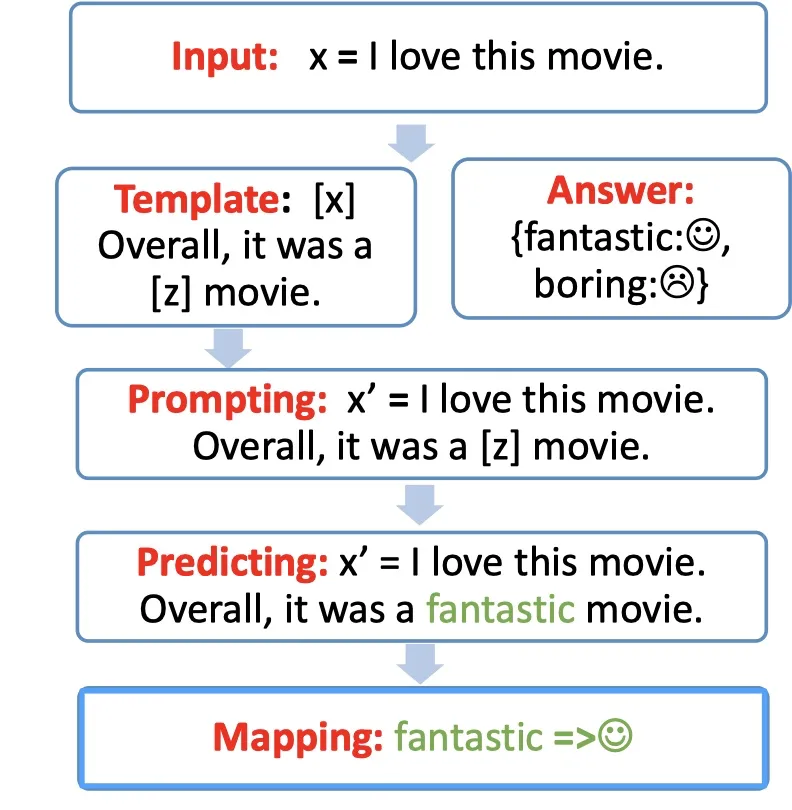

#### 4. Prompt-based Methods vs. Fine-tuning
Prompt-based methods and fine-tuning differ in how they adapt a pre-trained model to a downstream task. In standard fine-tuning, we mainly adapt the model by updating parameters and, in many cases, adding task-specific components. In prompt-based methods, the main idea is instead to adapt the task to the model by reformulating the input through prompts.

This difference is important because prompt-based methods often keep the task format closer to the original pre-training objective. In the basic prompting setting, they also usually avoid introducing new task-specific parameters, which makes them especially attractive in few-shot settings.

At the same time, not all prompt-based methods are completely training-free. Beyond manual prompting, some methods also optimize prompt-related parameters, such as continuous prompts, prefix tuning, and P-tuning. These methods are usually highly parameter-efficient, and some representative results show performance comparable to full fine-tuning while training only about 0.1%–3% of parameters.

## Part 3: Example of Prompting
To make the idea of prompt-based methods more concrete, we now walk through a simple example. We will follow the basic prompt-based workflow step by step: define a task, rewrite the input with a template, let the model make a prediction, and map the prediction back to the target label.

#### Step 1: Define a task
We begin with a simple sentiment classification task. Instead of directly training a classifier, we will use prompting to reformulate the task into a language-model-style prediction problem. For simplicity, we first prepare a small set of example inputs and their corresponding labels.

In [1]:
# A tiny sentiment classification dataset
examples = [
    {"text": "The movie was fantastic and full of energy.", "label": "positive"},
    {"text": "The plot was boring and difficult to follow.", "label": "negative"},
    {"text": "The acting was excellent and very convincing.", "label": "positive"},
    {"text": "The film was too long and not interesting.", "label": "negative"},
]

#### Step 2: Obtain a PLM
We begin with a simple sentiment classification task. In this example, we use prompting to guide a pretrained model to generate a natural language answer directly, instead of training a separate classifier.

In [15]:
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "google/flan-t5-base"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 768)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 768)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=768, out_features=768, bias=False)
              (k): Linear(in_features=768, out_features=768, bias=False)
              (v): Linear(in_features=768, out_features=768, bias=False)
              (o): Linear(in_features=768, out_features=768, bias=False)
              (relative_attention_bias): Embedding(32, 12)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseGatedActDense(
              (wi_0): Linear(in_features=768, out_features=2048, bias=False)
              (wi_1): Linear(in_features=768, out_features=2048, bias=False)
              (wo):

#### Step 3: Define a template
A prompt template rewrites the original input into a form that the model can answer to.

In [16]:
def apply_template(text: str) -> str:
    return (
        "Review: " + text + "\n"
        "Question: Is the sentiment of this review positive or negative?\n"
        "Answer:"
    )

#### Step 4: Define labels
Instead of asking the model to output class IDs directly, we define label words for each class. For example:
- positive $\rightarrow$ *great*
- negative $\rightarrow$ *terrible*

This is the answer-label mapping step in a prompt-based pipeline.

In [17]:
label_words = {
    "positive": "great",
    "negative": "terrible",
}

#### Step 5: Build prompted inputs
Now we convert each original example into its prompted form.

In [18]:
for ex in examples:
    prompted_text = apply_template(ex["text"])
    print(prompted_text)
    print("-" * 60)

Review: The movie was fantastic and full of energy.
Question: Is the sentiment of this review positive or negative?
Answer:
------------------------------------------------------------
Review: The plot was boring and difficult to follow.
Question: Is the sentiment of this review positive or negative?
Answer:
------------------------------------------------------------
Review: The acting was excellent and very convincing.
Question: Is the sentiment of this review positive or negative?
Answer:
------------------------------------------------------------
Review: The film was too long and not interesting.
Question: Is the sentiment of this review positive or negative?
Answer:
------------------------------------------------------------


#### Step 6: Run inference with the masked language model
We send the prompted text into the model, locate the [MASK] position, and compare the scores of the label words.

In [19]:
def generate_answer(text: str, model, tokenizer, device, max_new_tokens: int = 10):
    prompted_text = apply_template(text)

    inputs = tokenizer(prompted_text, return_tensors="pt", truncation=True).to(device)

    with torch.no_grad():
        output_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens
        )

    generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True).strip()

    return {
        "prompted_text": prompted_text,
        "generated_text": generated_text
    }

#### Step 7: Map predictions back to task labels
Finally, we run prediction on all examples and compare the outputs with the gold labels.

In [20]:
def map_to_label(generated_text: str) -> str:
    text = generated_text.lower()

    if "positive" in text:
        return "positive"
    elif "negative" in text:
        return "negative"
    else:
        return "unknown"


for ex in examples:
    result = generate_answer(ex["text"], model, tokenizer, device)
    predicted_label = map_to_label(result["generated_text"])

    print("Input:       ", ex["text"])
    print("Prompted:    ", result["prompted_text"])
    print("Model output:", result["generated_text"])
    print("Gold label:  ", ex["label"])
    print("Predicted:   ", predicted_label)
    print("-" * 60)

Input:        The movie was fantastic and full of energy.
Prompted:     Review: The movie was fantastic and full of energy.
Question: Is the sentiment of this review positive or negative?
Answer:
Model output: positive
Gold label:   positive
Predicted:    positive
------------------------------------------------------------
Input:        The plot was boring and difficult to follow.
Prompted:     Review: The plot was boring and difficult to follow.
Question: Is the sentiment of this review positive or negative?
Answer:
Model output: negative
Gold label:   negative
Predicted:    negative
------------------------------------------------------------
Input:        The acting was excellent and very convincing.
Prompted:     Review: The acting was excellent and very convincing.
Question: Is the sentiment of this review positive or negative?
Answer:
Model output: positive
Gold label:   positive
Predicted:    positive
------------------------------------------------------------
Input:        Th